SAHAN TEST 10 Students

In [1]:
%pip install statsmodels tqdm scikit-learn pandas numpy matplotlib seaborn joblib 

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [5]:
pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ASUS\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
# %%
import os, random
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================
# Reproducibility
# =====================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =====================
# Paths
# =====================
DATA_PATH = "data_sets/student_multi_10profiles_fullclasses_2015_2025.csv"
OUTPUT_DIR = "newdata/forecast_outputs"
MODEL_DIR = os.path.join(OUTPUT_DIR, "per_student_models")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# =====================
# Hyperparameters
# =====================
LOOKBACK = 60
HORIZON = 90
MIN_HISTORY_DAYS = 200
BATCH_SIZE = 16
EPOCHS = 40


In [3]:
# %%
df = pd.read_csv(DATA_PATH)

# Strip strings
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip()

# Parse dates
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.dropna(subset=['Timestamp'])
df['date_only'] = df['Timestamp'].dt.floor('D')

print("Rows after cleaning:", len(df))
df.head()


Rows after cleaning: 38650


,StudentID,Profile,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Respiration_Rate,Sleep_Duration,Activity_Levels,Mood,Cognitive_Load,Study_Hours,Academic_Stressors,Stress_Level,Mental_Health_Status,date_only
0,1,High_Achiever,2015-01-01,74.9,116.9,74.2,15.4,7.24,7019,Neutral,6,4.8,0,Medium,Normal,2015-01-01
1,1,High_Achiever,2015-01-02,69.8,120.2,74,14.7,6.16,5411,Sad,5,6.59,0,Medium,Mild Stress,2015-01-02
2,1,High_Achiever,2015-01-03,69.5,113.7,75.3,15.6,7.33,5627,Happy,5,4.67,1,Medium,Depression,2015-01-03
3,1,High_Achiever,2015-01-04,70.8,114.6,79.4,15.2,7.22,5051,Happy,6,6.19,0,Medium,Depression,2015-01-04
4,1,High_Achiever,2015-01-05,70.2,117.1,75.5,15.2,7.1,8066,Neutral,5,5.76,2,Medium,Depression,2015-01-05


In [4]:
# %%
stress_map = {"Low": 1, "Medium": 2, "High": 3}
mental_map = {
    "Normal": 1,
    "Mild Stress": 2,
    "Moderate Stress": 3,
    "Depression": 4,
    "Severe Stress": 5
}

df['Stress_Level_Score'] = df['Stress_Level'].map(stress_map)
df['Mental_Health_Status_Score'] = df['Mental_Health_Status'].map(mental_map)

df[['Stress_Level_Score','Mental_Health_Status_Score']] = (
    df[['Stress_Level_Score','Mental_Health_Status_Score']]
    .interpolate()
    .bfill()
)


In [5]:
# %%
# Predict CHANGES instead of absolute values
for col in ['Stress_Level_Score', 'Mental_Health_Status_Score']:
    df[f'{col}_delta'] = df.groupby('StudentID')[col].diff()

df[['Stress_Level_Score_delta',
    'Mental_Health_Status_Score_delta']] = (
    df[['Stress_Level_Score_delta',
        'Mental_Health_Status_Score_delta']]
    .fillna(0.0)
)


In [6]:
# %%
def build_student_daily_features(df_student):
    num_cols = df_student.select_dtypes(include=np.number).columns.tolist()
    agg = df_student.groupby('date_only')[num_cols].mean()
    agg = agg.asfreq('D').interpolate().ffill().bfill()

    # Calendar features
    agg['dayofweek'] = agg.index.dayofweek
    agg['month'] = agg.index.month
    agg['is_weekend'] = (agg['dayofweek'] >= 5).astype(int)

    # Rolling statistics
    base_cols = [
        'Stress_Level_Score',
        'Mental_Health_Status_Score',
        'Stress_Level_Score_delta',
        'Mental_Health_Status_Score_delta'
    ]

    for c in base_cols:
        if c in agg.columns:
            agg[f'{c}_rmean_7'] = agg[c].rolling(7, min_periods=1).mean()
            agg[f'{c}_rmean_30'] = agg[c].rolling(30, min_periods=1).mean()

    return agg


In [7]:
# %%
def make_sequences(X, y, lookback, horizon):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xs), np.array(ys)


In [8]:
# %%
def smooth_mse_loss(y_true, y_pred, lambda_smooth=0.2):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    smooth = tf.reduce_mean(tf.square(y_pred[:,1:] - y_pred[:,:-1]))
    return mse + lambda_smooth * smooth


In [9]:
# %%
targets = ['Stress_Level_Score_delta','Mental_Health_Status_Score_delta']
students = sorted(df['StudentID'].unique())

all_forecasts = []

for sid in students:
    df_s = df[df['StudentID'] == sid]
    if df_s.shape[0] < MIN_HISTORY_DAYS:
        continue

    feat = build_student_daily_features(df_s)

    X = feat.drop(columns=targets, errors='ignore').values
    y = feat[targets].values

    scaler_X = StandardScaler().fit(X)
    scaler_y = StandardScaler().fit(y)

    Xs = scaler_X.transform(X)
    ys = scaler_y.transform(y)

    X_seq, y_seq = make_sequences(Xs, ys, LOOKBACK, HORIZON)
    if X_seq.shape[0] < 10:
        continue

    y_flat = y_seq.reshape(y_seq.shape[0], -1)

    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, X_seq.shape[2])),
        Dropout(0.2),
        LSTM(32),
        Dense(y_flat.shape[1])
    ])

    model.compile(
        optimizer='adam',
        loss=lambda yt, yp: smooth_mse_loss(yt, yp, 0.2)
    )

    model.fit(X_seq, y_flat, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

    # Forecast
    X_last = Xs[-LOOKBACK:].reshape(1, LOOKBACK, Xs.shape[1])
    y_pred = model.predict(X_last).reshape(HORIZON, len(targets))
    y_delta = scaler_y.inverse_transform(y_pred)

    # Reconstruct absolute values
    last_known = feat[['Stress_Level_Score','Mental_Health_Status_Score']].iloc[-1].values
    y_abs = np.cumsum(y_delta, axis=0) + last_known

    dates = [feat.index[-1] + timedelta(days=i+1) for i in range(HORIZON)]
    out = pd.DataFrame(y_abs, columns=['Stress_Level_Score','Mental_Health_Status_Score'], index=dates)
    out['StudentID'] = sid

    all_forecasts.append(out)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


In [10]:
# %%
def human_smooth(series, alpha=0.25, max_daily_change=0.4):
    out = [series[0]]
    for i in range(1, len(series)):
        raw = alpha * series[i] + (1 - alpha) * out[-1]
        diff = np.clip(raw - out[-1], -max_daily_change, max_daily_change)
        out.append(out[-1] + diff)
    return np.array(out)


In [11]:
# %%
combined = pd.concat(all_forecasts).reset_index().rename(columns={'index':'date'})

for c in ['Stress_Level_Score','Mental_Health_Status_Score']:
    combined[c] = human_smooth(combined[c].values)

combined.to_csv(os.path.join(OUTPUT_DIR, "all_students_3mo_forecasts.csv"), index=False)
combined.head()


,date,Stress_Level_Score,Mental_Health_Status_Score,StudentID
0,2025-08-01,1.879302,4.728658,1
1,2025-08-02,1.875426,4.723555,1
2,2025-08-03,1.882661,4.743410,1
3,2025-08-04,1.896584,4.794494,1
4,2025-08-05,1.916278,4.865096,1


In [12]:
# %%
inv_stress = {1:"Low",2:"Medium",3:"High"}
inv_mental = {1:"Normal",2:"Mild Stress",3:"Moderate Stress",4:"Depression",5:"Severe Stress"}

def to_label(x, inv_map):
    x = int(np.clip(round(x), min(inv_map), max(inv_map)))
    return inv_map[x]

combined['Stress_Label'] = combined['Stress_Level_Score'].apply(lambda x: to_label(x, inv_stress))
combined['Mental_Label'] = combined['Mental_Health_Status_Score'].apply(lambda x: to_label(x, inv_mental))


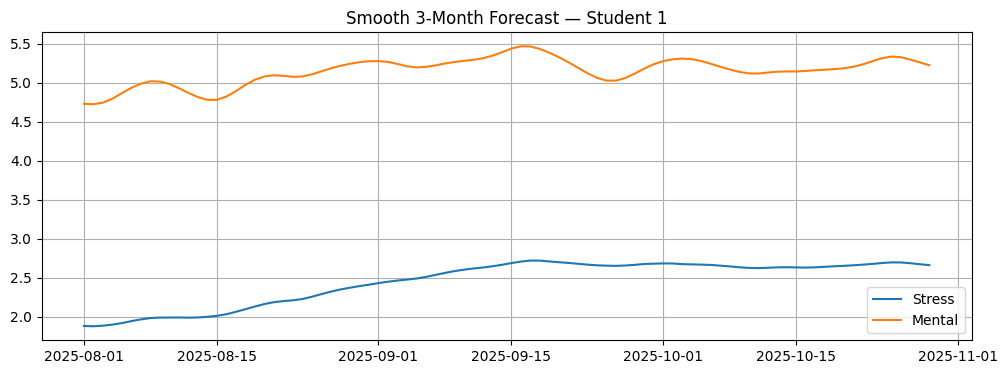

In [14]:
# %%
sid = combined['StudentID'].iloc[0]
sub = combined[combined['StudentID']==sid]

plt.figure(figsize=(12,4))
plt.plot(sub['date'], sub['Stress_Level_Score'], label='Stress')
plt.plot(sub['date'], sub['Mental_Health_Status_Score'], label='Mental')
plt.title(f"Smooth 3-Month Forecast — Student {sid}")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
#quickly previews labeled forecasts for multiple students by opening
#a few per-student CSV files and displaying the first and last days of their 3-month stress and mental-health predictions
# %%
import pandas as pd
OUT_LABELED_DIR = "newdata/forecast_outputs/per_student_labeled_3mo"  # adjust if needed

def show_students(n=3):
    files = sorted([f for f in os.listdir(OUT_LABELED_DIR) if f.endswith('.csv')])[:n]
    for f in files:
        path = os.path.join(OUT_LABELED_DIR, f)
        df = pd.read_csv(path, parse_dates=['date'])
        sid = f.split('_')[1]  # 'student_1_labeled_3mo.csv' -> '1'
        print(f"\n=== Student {sid} — first 10 rows ===")
        display(df[['date','stress_pred_label','mental_pred_label']].head(60))
        print(f"... last 10 rows for Student {sid} ...")
        display(df[['date','stress_pred_label','mental_pred_label']].tail(30))

show_students(n=5)  # change n to view more students



=== Student 10 — first 10 rows ===


,date,stress_pred_label,mental_pred_label
0,2025-08-01,Medium,Moderate Stress
1,2025-08-02,Medium,Moderate Stress
2,2025-08-03,Medium,Moderate Stress
3,2025-08-04,Medium,Moderate Stress
4,2025-08-05,Medium,Moderate Stress
5,2025-08-06,Medium,Moderate Stress
6,2025-08-07,Medium,Moderate Stress
7,2025-08-08,Medium,Moderate Stress
8,2025-08-09,Medium,Moderate Stress
9,2025-08-10,Medium,Moderate Stress


... last 10 rows for Student 10 ...


,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression



=== Student 1 — first 10 rows ===


...

,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression



=== Student 4 — first 10 rows ===


,date,stress_pred_label,mental_pred_label
0,2025-08-01,Medium,Depression
1,2025-08-02,Medium,Depression
2,2025-08-03,Medium,Depression
3,2025-08-04,Medium,Depression
4,2025-08-05,Medium,Depression
5,2025-08-06,Medium,Depression
6,2025-08-07,Medium,Depression
7,2025-08-08,Medium,Depression
8,2025-08-09,Medium,Depression
9,2025-08-10,Medium,Depression


... last 10 rows for Student 4 ...


,date,stress_pred_label,mental_pred_label
60,2025-09-30,High,Depression
61,2025-10-01,High,Depression
62,2025-10-02,High,Depression
63,2025-10-03,High,Depression
64,2025-10-04,High,Depression
65,2025-10-05,High,Depression
66,2025-10-06,High,Depression
67,2025-10-07,High,Depression
68,2025-10-08,High,Depression
69,2025-10-09,High,Depression


In [16]:
#prints the first 7 days of labeled stress and mental-health forecasts for each student
# %%
import pandas as pd
labeled_dir = "newdata/forecast_outputs/per_student_labeled_3mo"
files = sorted([f for f in os.listdir(labeled_dir) if f.endswith('.csv')])
for f in files:
    df = pd.read_csv(os.path.join(labeled_dir,f), parse_dates=['date'])
    sid = f.split('_')[1]
    print(f"\n--- Student {sid} daily labels (first 7 rows) ---")
    for _, r in df.head(7).iterrows():
        print(f"{r['date'].date()} : {r['stress_pred_label']} | {r['mental_pred_label']}")



--- Student 10 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02 : Medium | Moderate Stress
2025-08-03 : Medium | Moderate Stress
2025-08-04 : Medium | Moderate Stress
2025-08-05 : Medium | Moderate Stress
2025-08-06 : Medium | Moderate Stress
2025-08-07 : Medium | Moderate Stress

--- Student 1 daily labels (first 7 rows) ---
2025-08-01 : Medium | Depression
2025-08-02 : Medium | Depression
2025-08-03 : Medium | Depression
2025-08-04 : Medium | Depression
2025-08-05 : Medium | Depression
2025-08-06 : Medium | Depression
2025-08-07 : Medium | Depression

--- Student 2 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02 : Medium | Moderate Stress
2025-08-03 : Medium | Moderate Stress
2025-08-04 : Medium | Moderate Stress
2025-08-05 : Medium | Moderate Stress
2025-08-06 : Medium | Moderate Stress
2025-08-07 : Medium | Moderate Stress

--- Student 3 daily labels (first 7 rows) ---
2025-08-01 : Medium | Moderate Stress
2025-08-02